In [3]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import h5py
import yaml
import os
import copy
import glob
import subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm
import pandas as pd
import shutil
from scipy.optimize import minimize
from scipy.stats import norm
import seaborn as sns
from numpy.fft import rfft, rfftfreq
import os
import copy
import yaml
import numpy as np
import pandas as pd
import corner
from scipy.stats import lognorm

In [4]:
def load_stellar_grid(filename):
    """Loads all physically valid stellar states from the HDF5 grid."""
    print("Loading stellar grid...")
    valid_stars = []
    
    def get_data(obj, field):
        if isinstance(obj, h5py.Dataset):
            return obj[field]
        else:
            return obj[field][:]

    with h5py.File(filename, 'r') as f:
        for key in f.keys():
            try:
                group = f[key]
                g_data = group['global']
                
                teffs = get_data(g_data, 'teff')
                loggs = get_data(g_data, 'logg')
                
                try:
                    mass = float(group['parameters/mass0'][()])
                except:
                    mass = float(get_data(g_data, 'mass')[0])
                
                # Add every evolutionary stage along this track
                for i in range(len(teffs)):
                    valid_stars.append({
                        "mass": mass,
                        "teff": float(teffs[i]),
                        "logg": float(loggs[i])
                    })
            except Exception:
                continue

In [9]:
# # --- Setup ---
# with open("../psls-1.9/psls.yaml", "r") as file:
#     base_config = yaml.safe_load(file)

# stellar_grid = load_stellar_grid("../psls-1.9/grid_plato.hdf5")
# os.makedirs("configs", exist_ok=True)
# metadata_records = []

# # --- Config ---
# num_systems = 1_000
# anomaly_classes = np.repeat([0, 1, 2, 3], num_systems // 4)
# np.random.shuffle(anomaly_classes)

# for i, anomaly_type in enumerate(anomaly_classes):
#     system_config = copy.deepcopy(base_config)
#     seed = int(np.random.randint(1000000, 9999999))
#     system_config['Observation']['MasterSeed'] = seed

#     # Gaps: always off — applied in postprocessing
#     system_config['Observation']['Gaps']['Enable'] = 0

#     star = np.random.choice(stellar_grid)
#     system_config['Star']['Teff'] = star["teff"]
#     system_config['Star']['Logg'] = star["logg"]

#     has_flares  = anomaly_type in (1, 3)
#     has_transit = anomaly_type in (2, 3)

#     # --- Flares ---
#     system_config['Activity']['Flare']['Enable'] = int(has_flares)
#     flare_amplitude = 0
#     if has_flares:
#         flare_amplitude = float(np.exp(np.random.uniform(np.log(500), np.log(20000))))
#         mean_dur = float(np.random.uniform(0.01, 0.1))
#         system_config['Activity']['Flare']['Amplitude']          = flare_amplitude
#         system_config['Activity']['Flare']['MeanPeriod']         = float(np.random.uniform(1.0, 15.0))
#         system_config['Activity']['Flare']['MeanDuration']       = mean_dur
#         system_config['Activity']['Flare']['DurationDispersion'] = mean_dur * 0.2
#         system_config['Activity']['Flare']['UpDown']             = float(np.random.uniform(0.05, 0.3))

#     # --- Transits ---
#     system_config['Transit']['Enable'] = int(has_transit)
#     transit_period = 0
#     radius_earth   = 0
#     if has_transit:
#         period_days   = np.exp(np.random.uniform(np.log(2.0), np.log(100.0)))
#         period_years  = period_days / 365.25
#         a_au          = (star["mass"] * (period_years ** 2)) ** (1 / 3)
#         radius_earth  = np.random.lognormal(mean=np.log(1.7), sigma=1.0)
#         transit_period = float(period_days)
#         system_config['Transit']['OrbitalPeriod']        = transit_period
#         system_config['Transit']['PlanetSemiMajorAxis']  = float(a_au)
#         system_config['Transit']['PlanetRadius']         = float(max(0.1, radius_earth) / 11.20)

#     #randomy pick a drift level for the systematics
#     drift_levels = ['low', 'medium', 'high', 'max']

#     drift = str(np.random.choice(drift_levels))
#     print(f"System {1000+i:04d}: Drift level set to '{drift}'")
#     system_config['Instrument']['Systematics']['DriftLevel'] = drift

#     filename = f"configs/sys_{1000+i:04d}.yaml"
#     with open(filename, "w") as out_file:
#         yaml.safe_dump(system_config, out_file, default_flow_style=False)

#     metadata_records.append({
#         "system_id":           f"sys_{i:04d}",
#         "master_seed":         seed,
#         "anomaly_class":       anomaly_type,
#         "label_has_flares":    int(has_flares),
#         "label_has_transit":   int(has_transit),
#         "star_mass":           star["mass"],
#         "star_teff":           star["teff"],
#         "star_logg":           star["logg"],
#         "flare_amplitude":     flare_amplitude,
#         "transit_period":      transit_period,
#         "transit_radius_earth": radius_earth
#         #"drift": drift
#     })

# df_metadata = pd.DataFrame(metadata_records)
# df_metadata.to_csv("paired_simulation_labels.csv", index=False)
# print(f"Done. Generated {num_systems} configs.")

In [10]:
# # --- Setup ---
# with open("../psls-1.9/psls.yaml", "r") as file:
#     base_config = yaml.safe_load(file)

# stellar_grid = load_stellar_grid("../psls-1.9/grid_plato.hdf5")
# os.makedirs("configs", exist_ok=True)
# metadata_records = []

# # --- Config ---
# num_systems = 1_000
# anomaly_classes = np.repeat([0, 1, 2, 3], num_systems // 4)
# np.random.shuffle(anomaly_classes)

# for i, anomaly_type in enumerate(anomaly_classes):
#     system_config = copy.deepcopy(base_config)
#     seed = int(np.random.randint(1000000, 9999999))
#     system_config['Observation']['MasterSeed'] = seed

#     # Gaps: always off — applied in postprocessing
#     system_config['Observation']['Gaps']['Enable'] = 0

#     star = np.random.choice(stellar_grid)
#     system_config['Star']['Teff'] = star["teff"]
#     system_config['Star']['Logg'] = star["logg"]

#     has_flares  = anomaly_type in (1, 3)
#     has_transit = anomaly_type in (2, 3)

#     # --- Flares ---
#     system_config['Activity']['Flare']['Enable'] = int(has_flares)
#     flare_amplitude = 0
#     if has_flares:
#         flare_amplitude = float(np.exp(np.random.uniform(np.log(500), np.log(20000))))
#         mean_dur = float(np.random.uniform(0.01, 0.1))
#         system_config['Activity']['Flare']['Amplitude']          = flare_amplitude
#         system_config['Activity']['Flare']['MeanPeriod']         = float(np.random.uniform(1.0, 15.0))
#         system_config['Activity']['Flare']['MeanDuration']       = mean_dur
#         system_config['Activity']['Flare']['DurationDispersion'] = mean_dur * 0.2
#         system_config['Activity']['Flare']['UpDown']             = float(np.random.uniform(0.05, 0.3))

#     # --- Transits ---
#     system_config['Transit']['Enable'] = int(has_transit)
#     transit_period = 0
#     radius_earth   = 0
#     if has_transit:
#         period_days   = np.exp(np.random.uniform(np.log(2.0), np.log(100.0)))
#         period_years  = period_days / 365.25
#         a_au          = (star["mass"] * (period_years ** 2)) ** (1 / 3)
#         radius_earth  = np.random.lognormal(mean=np.log(1.7), sigma=1.0)
#         transit_period = float(period_days)
#         system_config['Transit']['OrbitalPeriod']        = transit_period
#         system_config['Transit']['PlanetSemiMajorAxis']  = float(a_au)
#         system_config['Transit']['PlanetRadius']         = float(max(0.1, radius_earth) / 11.20)

#     #randomy pick a drift level for the systematics
#     drift_levels = ['low', 'medium', 'high', 'max']

#     drift = str(np.random.choice(drift_levels))
#     print(f"System {1000+i:04d}: Drift level set to '{drift}'")
#     system_config['Instrument']['Systematics']['DriftLevel'] = drift

#     filename = f"configs/sys_{1000+i:04d}.yaml"
#     with open(filename, "w") as out_file:
#         yaml.safe_dump(system_config, out_file, default_flow_style=False)

#     metadata_records.append({
#         "system_id":           f"sys_{1000+i:04d}",
#         "master_seed":         seed,
#         "anomaly_class":       anomaly_type,
#         "label_has_flares":    int(has_flares),
#         "label_has_transit":   int(has_transit),
#         "star_mass":           star["mass"],
#         "star_teff":           star["teff"],
#         "star_logg":           star["logg"],
#         "flare_amplitude":     flare_amplitude,
#         "transit_period":      transit_period,
#         "transit_radius_earth": radius_earth,
#         "drift": drift
#     })

# df_metadata = pd.DataFrame(metadata_records)
# df_metadata.to_csv("paired_simulation_labels_drift.csv", index=False)
# print(f"Done. Generated {num_systems} configs.")

In [11]:
# print("Combining CSV files...")
# # Load the datasets
# df_clean = pd.read_csv("paired_simulation_labels.csv")
# df_drift = pd.read_csv("paired_simulation_labels_drift.csv")

# # Add the 'drift' column to the clean data
# df_clean["drift"] = "none"

# # Combine into a single dataframe
# df_combined = pd.concat([df_clean, df_drift], ignore_index=True)

# # Save the new master CSV
# combined_csv_path = "paired_simulation_labels_combined.csv"
# df_combined.to_csv(combined_csv_path, index=False)
# print(f"Saved combined dataset to {combined_csv_path} ({len(df_combined)} rows total).\n")

In [1]:
#!python -u run_simulations.py

This notebook does the following. We begin by generating 1,000 samples without drift. We then generate 490 samples with drift. Finally, we combine the two datasets into one, entitled 'paired_simulation_labels_combined.csv'

There are several parameter choices that we used when generating the data. This will be highlighted below.

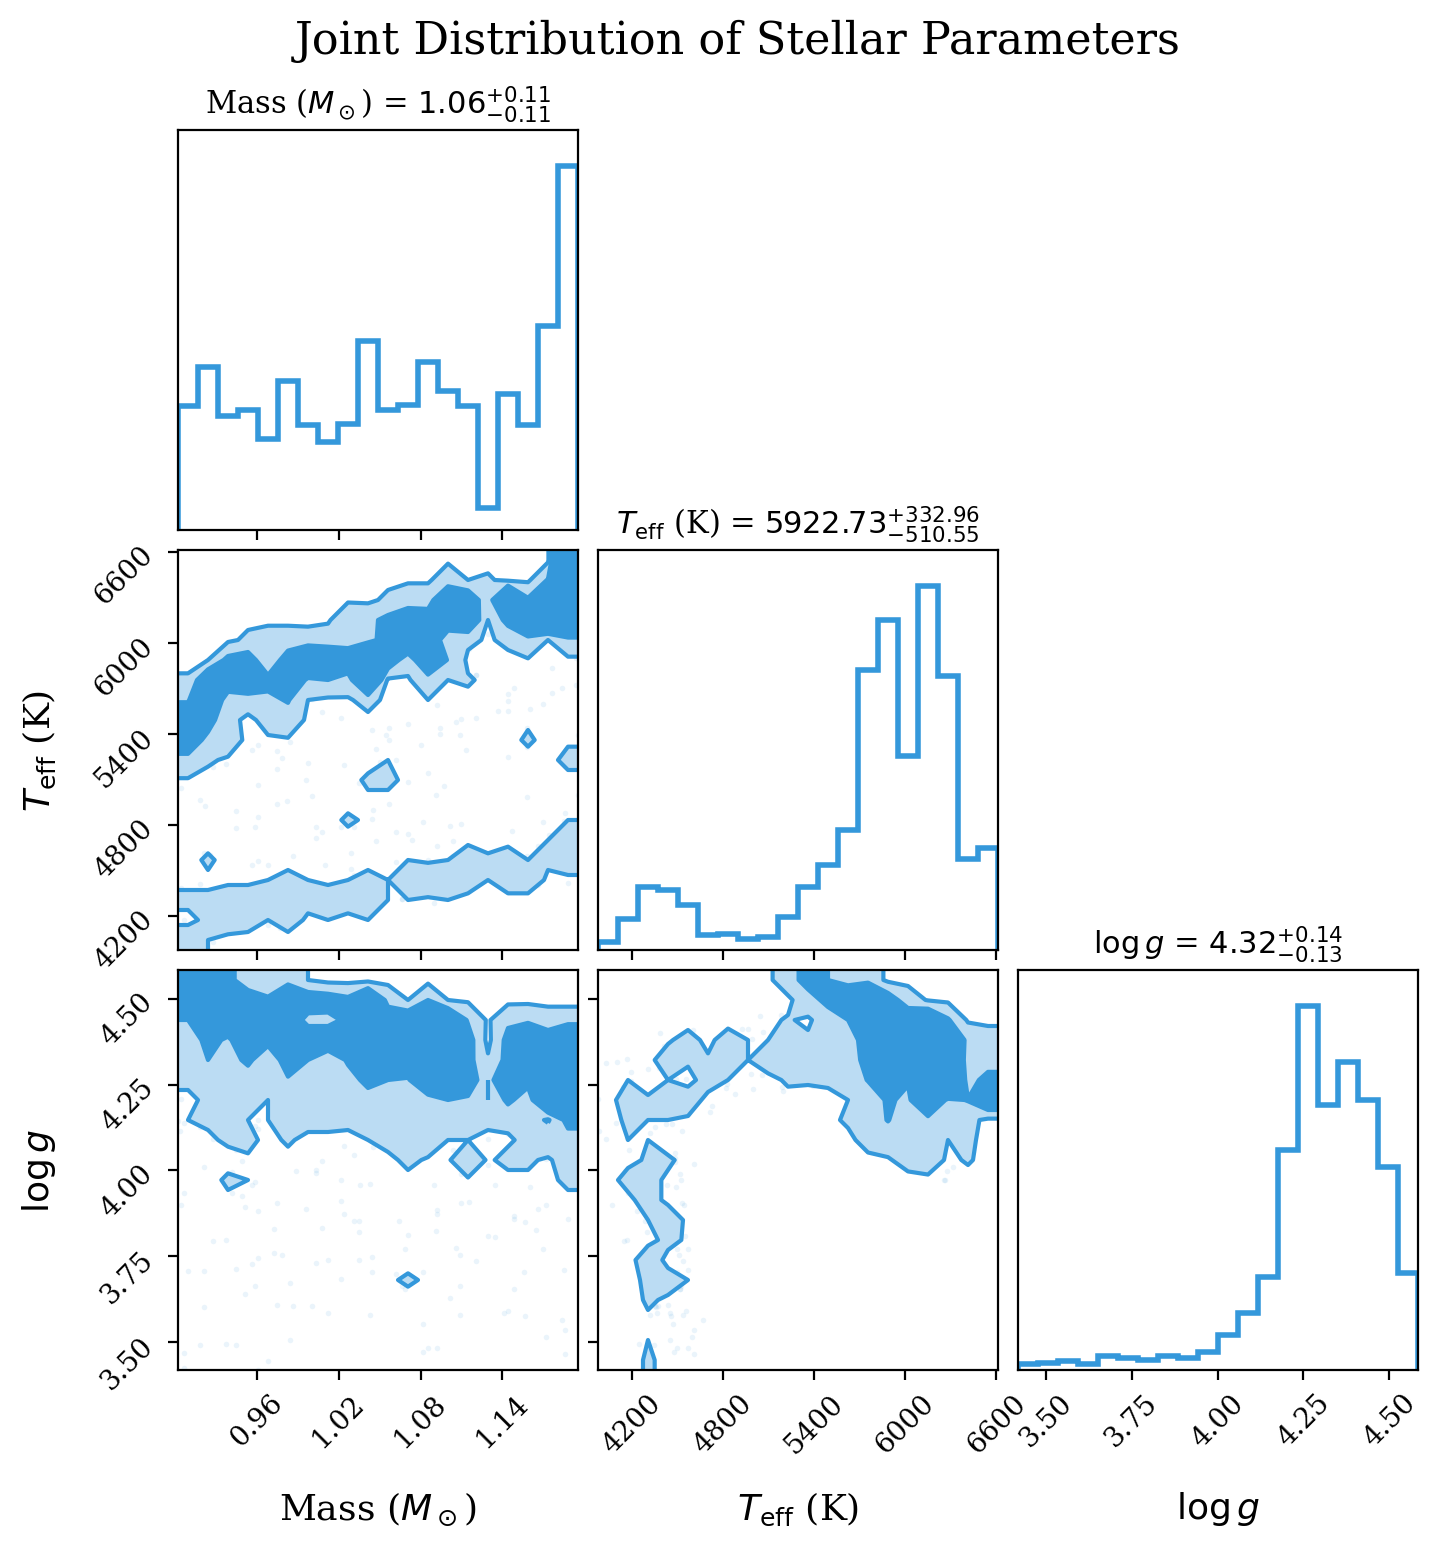

In [14]:

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 12,
    "figure.dpi": 200
})

theme_color = "#3498db"


df = pd.read_csv("paired_simulation_labels_combined.csv")

stellar_data = df[['star_mass', 'star_teff', 'star_logg']].dropna().values

fig_corner = corner.corner(
    stellar_data,
    labels=[r"Mass ($M_\odot$)", r"$T_{\rm eff}$ (K)", r"$\log g$"],
    color=theme_color,
    show_titles=True,
    title_kwargs={"fontsize": 11},
    hist_kwargs={"linewidth": 2},
    label_kwargs={"fontsize": 13},
    plot_datapoints=True,
    fill_contours=True,
    levels=(0.68, 0.95)
)

fig_corner.suptitle(
    "Joint Distribution of Stellar Parameters",
    y=1.02,
    fontsize=16
)

plt.savefig("thesis_stellar_corner.pdf", bbox_inches='tight')
plt.show()

For the stellar parameters above, we are limited based on the pre-computed oscillation models for PSLS. We directly sample elements on the grid of precomputed stars. The stellar temperatures are mostly solar-like, as is their mass. PSLS is designed to detect planets around Sun-like stars, so it works out fine for this analysis.

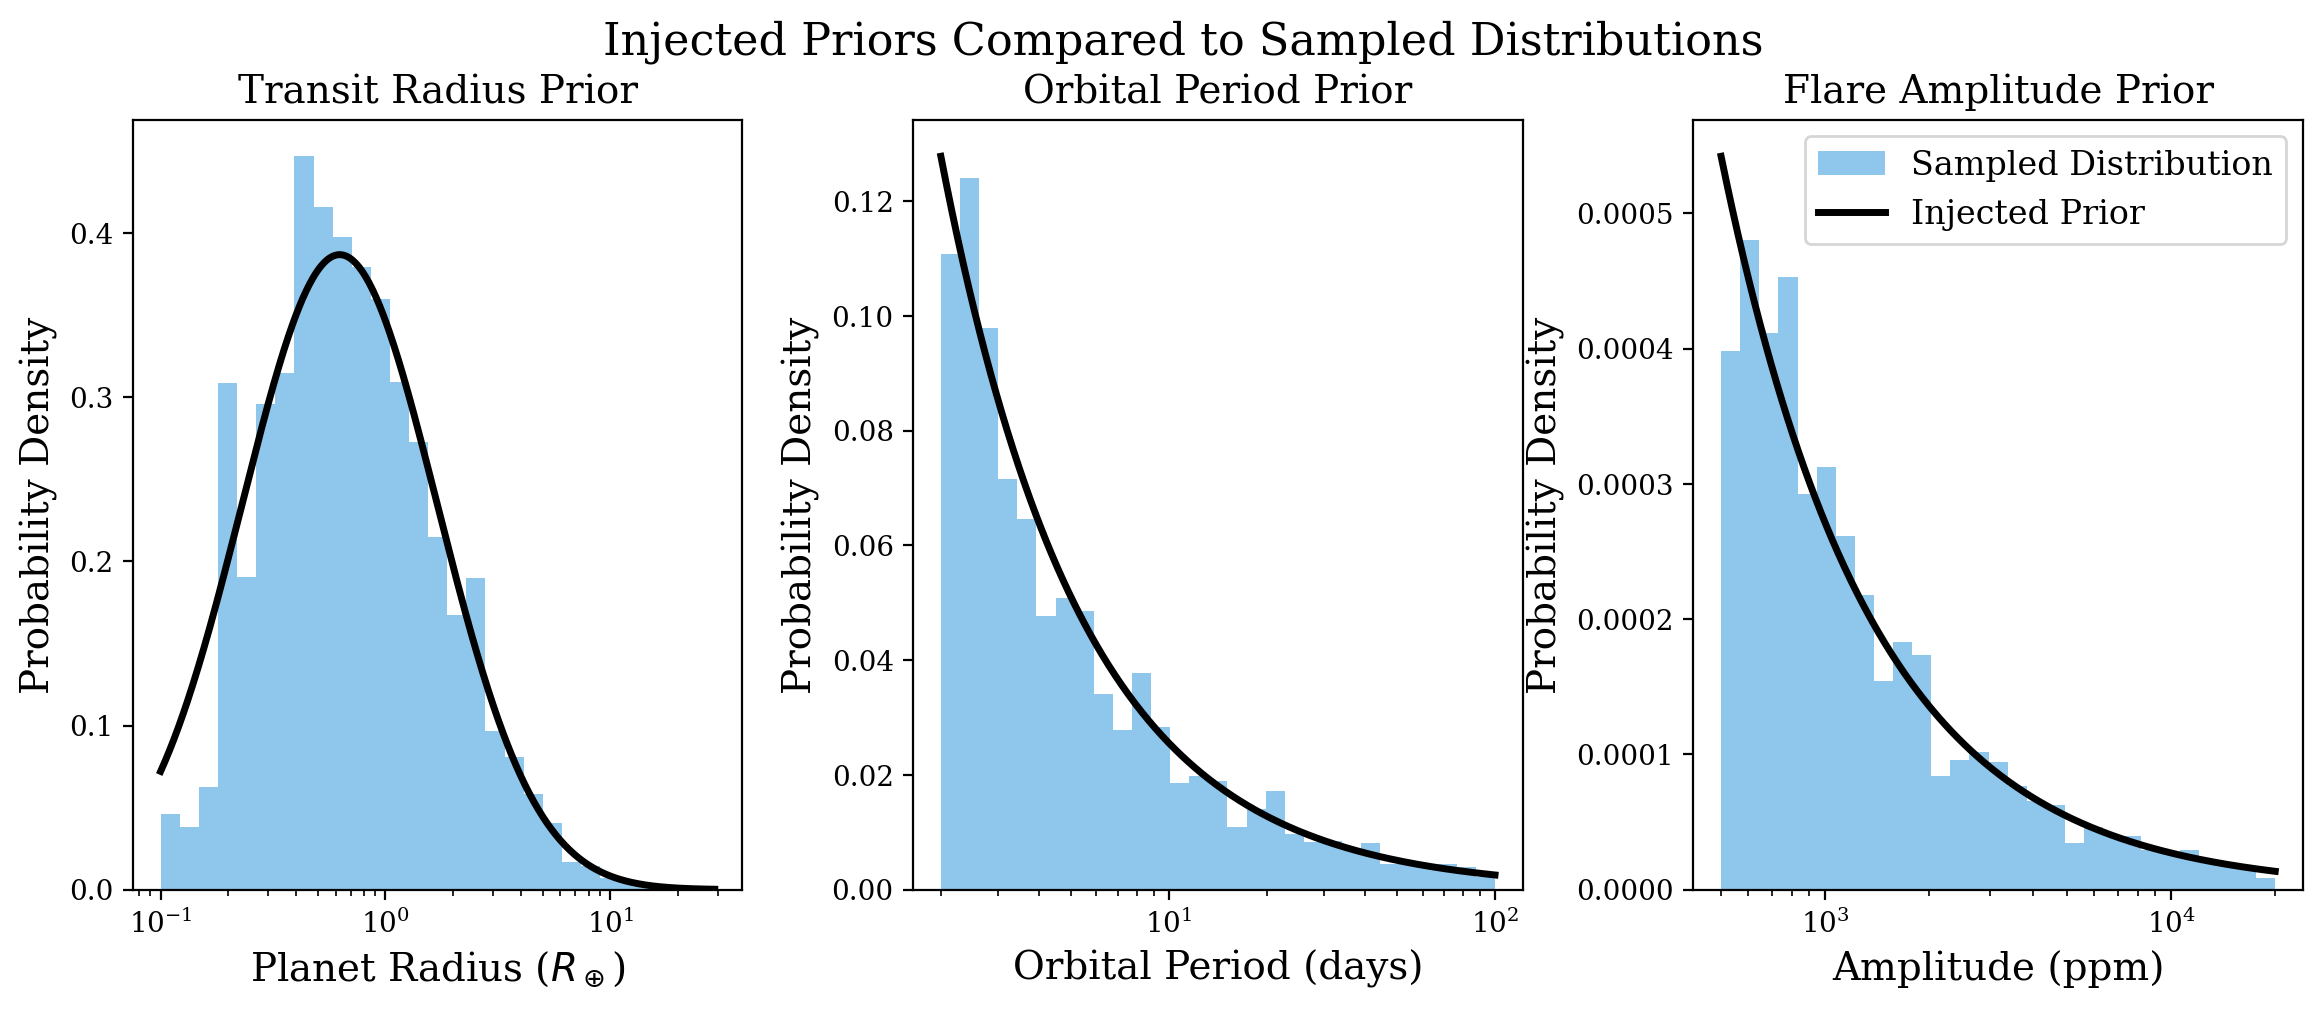

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.subplots_adjust(hspace=0.35, wspace=0.28)

flares = df[df['flare_amplitude'] > 0]
transits = df[df['transit_period'] > 0]


ax = axes[0]

data_rad = transits['transit_radius_earth']

bins_rad = np.logspace(
    np.log10(0.1),
    np.log10(data_rad.max()),
    30
)

ax.hist(
    data_rad,
    bins=bins_rad,
    density=True,
    color=theme_color,
    alpha=0.55
)

# Analytical prior
x_rad = np.logspace(np.log10(0.1), np.log10(data_rad.max()), 500)

pdf_rad = lognorm.pdf(
    x_rad,
    s=1.0,
    scale=np.exp(np.log(1.7))
)

ax.plot(
    x_rad,
    pdf_rad,
    color='black',
    linewidth=2.5,
    label='Injected Prior'
)

ax.set_xscale('log')
ax.set_title('Transit Radius Prior')
ax.set_xlabel(r'Planet Radius ($R_\oplus$)')
ax.set_ylabel('Probability Density')

# ==========================================
# B. Transit Period (Log-Uniform)
# ==========================================
ax = axes[1]

data_per = transits['transit_period']

bins_per = np.logspace(np.log10(2.0), np.log10(100.0), 30)

ax.hist(
    data_per,
    bins=bins_per,
    density=True,
    color=theme_color,
    alpha=0.55
)

x_per = np.logspace(np.log10(2.0), np.log10(100.0), 500)

# Proper log-uniform PDF in linear space
pdf_per = 1.0 / (
    x_per * (np.log(100.0) - np.log(2.0))
)

ax.plot(
    x_per,
    pdf_per,
    color='black',
    linewidth=2.5
)

ax.set_xscale('log')
ax.set_title('Orbital Period Prior')
ax.set_xlabel('Orbital Period (days)')
ax.set_ylabel('Probability Density')

# ==========================================
# C. Flare Amplitude (Log-Uniform)
# ==========================================
ax = axes[2]

data_amp = flares['flare_amplitude']

bins_amp = np.logspace(np.log10(500), np.log10(20000), 30)

ax.hist(
    data_amp,
    bins=bins_amp,
    density=True,
    color=theme_color,
    alpha=0.55,
    label='Sampled Distribution'
)

x_amp = np.logspace(np.log10(500), np.log10(20000), 500)

pdf_amp = 1.0 / (
    x_amp * (np.log(20000) - np.log(500))
)

ax.plot(
    x_amp,
    pdf_amp,
    color='black',
    linewidth=2.5,
    label='Injected Prior'
)

ax.set_xscale('log')
ax.set_title('Flare Amplitude Prior')
ax.set_xlabel('Amplitude (ppm)')
ax.set_ylabel('Probability Density')
ax.legend()


plt.suptitle(
    "Injected Priors Compared to Sampled Distributions",
    fontsize=16,
    y=0.98
)

plt.show()

It is believed that flare amplitudes follow a power law distribution. This is what we choose to sample from. However, we lower the slope of the lower law to ensure we have some events with high amplitudes as well. The planet radius distribution has been shown to be bimodal, with peaks below and above ~ 2 solar masses. In order to push our model to its limits, we generate planets with radii that will be too small for detection, so we better understand the sensitivity. Exoplanets have been to have wide ranges of orbital periods, from days to many years. Since our samples are under 300 days, we set a maximum period to be 100 days to ensure we get at least two transits. 